# 🏦 Automated Credit Scoring Pipeline & Modular Preprocessing

## 1. Resumen Ejecutivo
Este proyecto desarrolla un **Pipeline de Machine Learning** robusto para la predicción de riesgo crediticio (Loan Approval). El núcleo del trabajo reside en la transición de scripts de limpieza manuales hacia una **arquitectura de software orientada a MLOps**, utilizando transformadores personalizados compatibles con el ecosistema de `scikit-learn`.

## 2. El Desafío: Baja Discriminación y Ruido en los Datos
Durante la fase de Análisis Exploratorio (EDA), se identificó que el dataset presenta distribuciones altamente solapadas en variables de activos.

* **Hallazgo Clave:** El análisis de **Information Value (IV)** confirmó que, sin un tratamiento adecuado, el ruido de las variables de activos diluye la señal predictiva. La estrategia de binning y cálculo de pesos fue fundamental para rescatar el valor de estas características.

## 3. Innovación Técnica: Framework de Preprocesamiento Profesional
Para asegurar la escalabilidad y evitar el **Data Leakage**, se diseñaron transformadores de clase que encapsulan lógica de negocio compleja:

* **`WoeGenerator`**: Automatiza la codificación *Weight of Evidence*. A diferencia de implementaciones básicas, esta clase **aprende los límites de los intervalos (bin edges)** únicamente en el set de entrenamiento y los aplica de forma consistente en la inferencia, garantizando la integridad estadística del modelo.
* **`RatioGenerator` & `TotalAssetsGenerator`**: Permiten realizar ingeniería de variables (como el ratio deuda/ingreso o agregación de patrimonio) directamente dentro del flujo del Pipeline.
* **Selección Automática de Características**: El pipeline integra un filtro dinámico que descarta variables con un IV inferior al umbral técnico, manteniendo solo las variables con poder predictivo real: `loan_income_ratio`, `total_asset`, `loan_term` y `cibil_score`.

## 4. Resultados y Potencial de Negocio
Utilizando una **Regresión Logística** (modelo preferido en banca por su interpretabilidad y cumplimiento regulatorio como IFRS 9), se alcanzaron métricas de alto desempeño:

| Métrica | Clase 0 (Approved) | Clase 1 (Rejected) | Total / Accuracy |
| :--- | :---: | :---: | :---: |
| **Precision** | 0.98 | 0.94 | - |
| **Recall** | 0.96 | 0.96 | - |
| **F1-Score** | 0.97 | 0.95 | **0.96** |

**Conclusión:** La arquitectura implementada permitió que un modelo lineal igualara o superara el rendimiento de modelos de ensamble complejos (XGBoost/Random Forest) reportados en la literatura del dataset, manteniendo una transparencia total en la toma de decisiones crediticias.

## 5. Stack Tecnológico
* **Lenguaje:** Python (Pandas, NumPy).
* **ML Framework:** Scikit-Learn (Pipelines, ColumnTransformer, BaseEstimator).
* **Técnicas Especializadas:** Credit Scoring, WoE/IV Encoding, Feature Engineering, Prevención de Data Leakage.

In [118]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


In [119]:
from sklearn.preprocessing import StandardScaler,OrdinalEncoder,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,roc_curve,roc_auc_score

In [120]:
url = "https://raw.githubusercontent.com/MrPinkiePie/Loan-Approval-Prediction/refs/heads/main/loan_approval_dataset.csv"
data = pd.read_csv(url)

In [121]:
obj_cols = data.select_dtypes(['object']).columns
data[obj_cols] = data[obj_cols].apply(lambda x: x.str.strip())

data.columns = data.columns.str.strip()
map = {"Approved":0,"Rejected":1}
data.loan_status = data.loan_status.str.strip().map(map)
data.drop("loan_id",axis=1,inplace=True)
data.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


##EDA

### Análisis Univariado

In [132]:
cat_cols = ["no_of_dependents","education","self_employed","loan_term"]
num_cols = ["income_annum","loan_amount","cibil_score","residential_assets_value","commercial_assets_value","luxury_assets_value","bank_asset_value"]

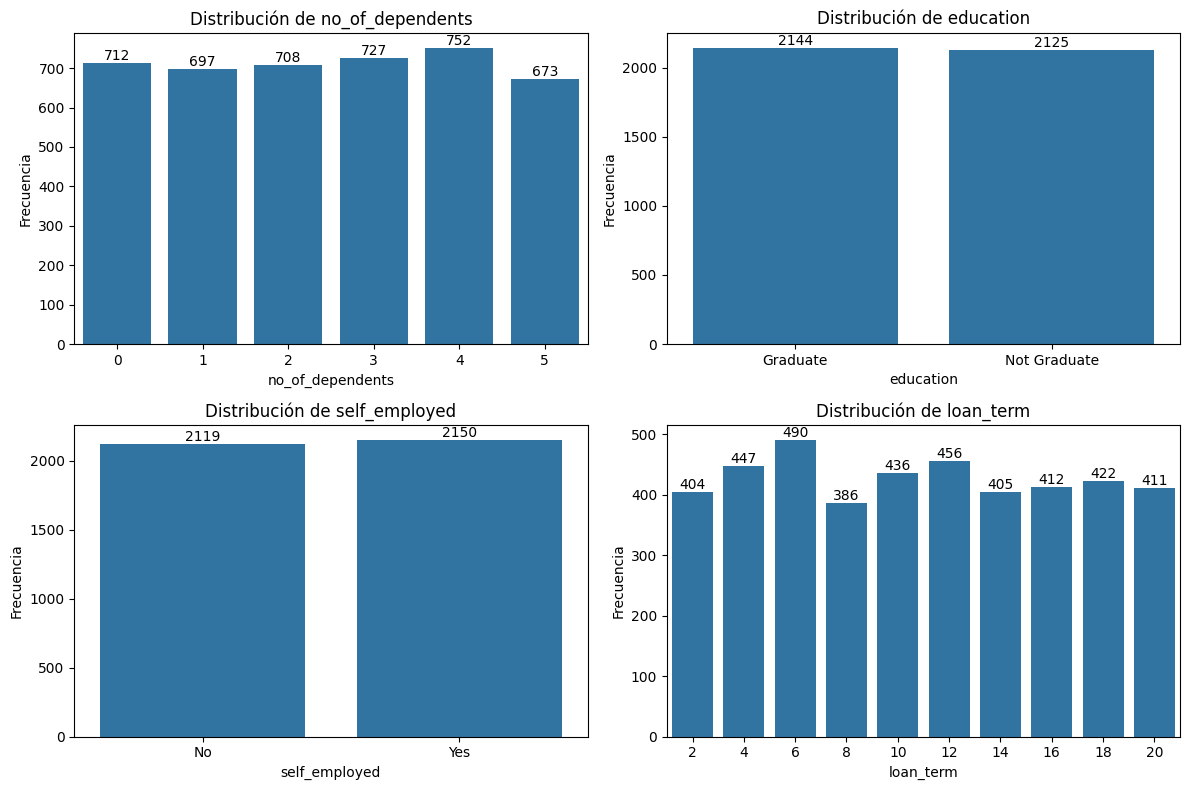

In [136]:
fig, axes = plt.subplots(2,2,figsize = (12,8))

for col, ax in zip(cat_cols, axes.flatten()[:len(cat_cols)]):
  sns.countplot(data = data, x = col, ax = ax)
  for container in ax.containers:
    ax.bar_label(container)
  ax.set_title(f"Distribución de {col}")
  ax.set_xlabel(col)
  ax.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

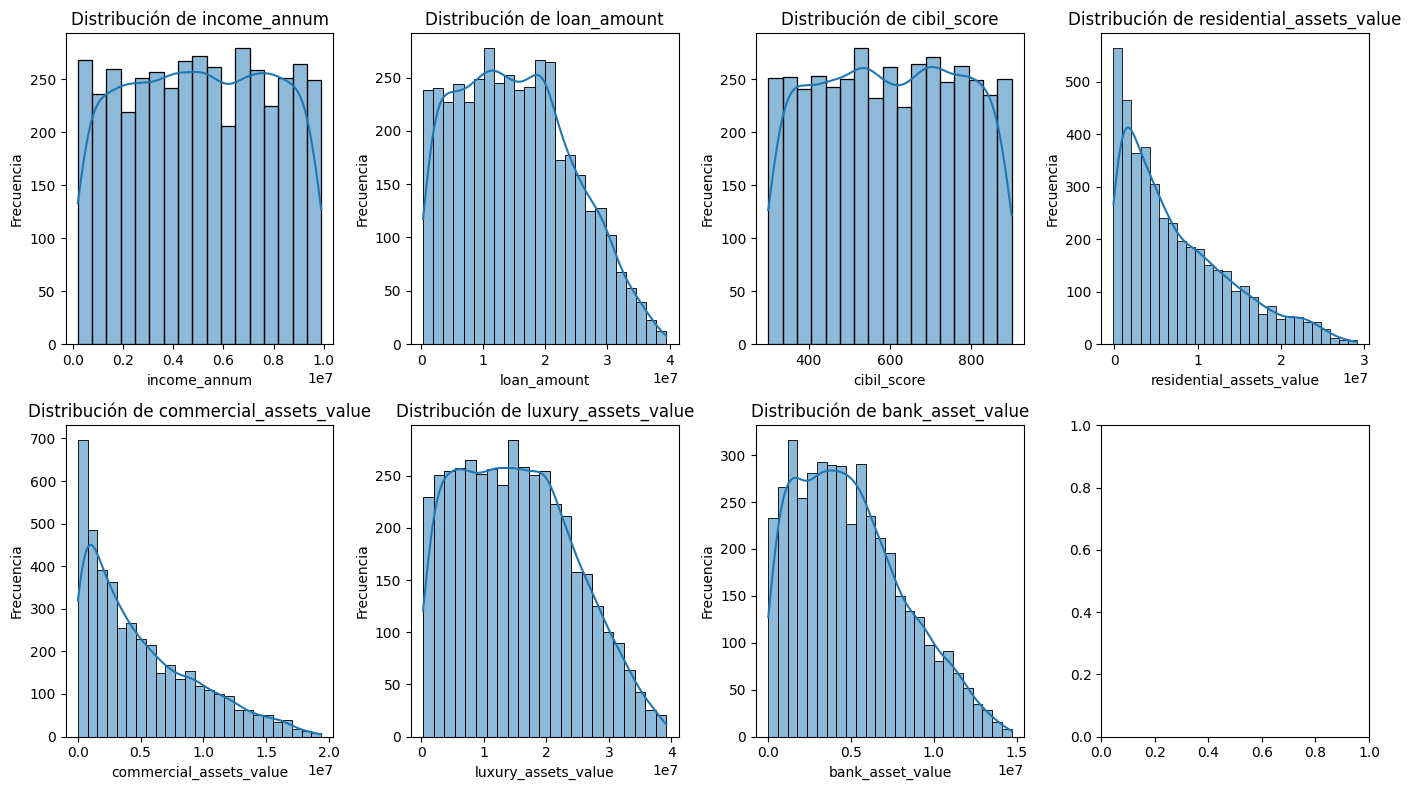

In [138]:
fig, axes = plt.subplots(2,4,figsize = (14,8))

for col, ax in zip(num_cols, axes.flatten()[:len(num_cols)]):
  sns.histplot(data = data, x = col, ax = ax,kde = True)
  ax.set_title(f"Distribución de {col}")
  ax.set_xlabel(col)
  ax.set_ylabel("Frecuencia")

plt.tight_layout()
plt

Identificamos que es una base de datos sintética al ver el histograma del ingreso con una distribución uniforme en lugar de asimetría con cola derecha

### Análisis Bivariado

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

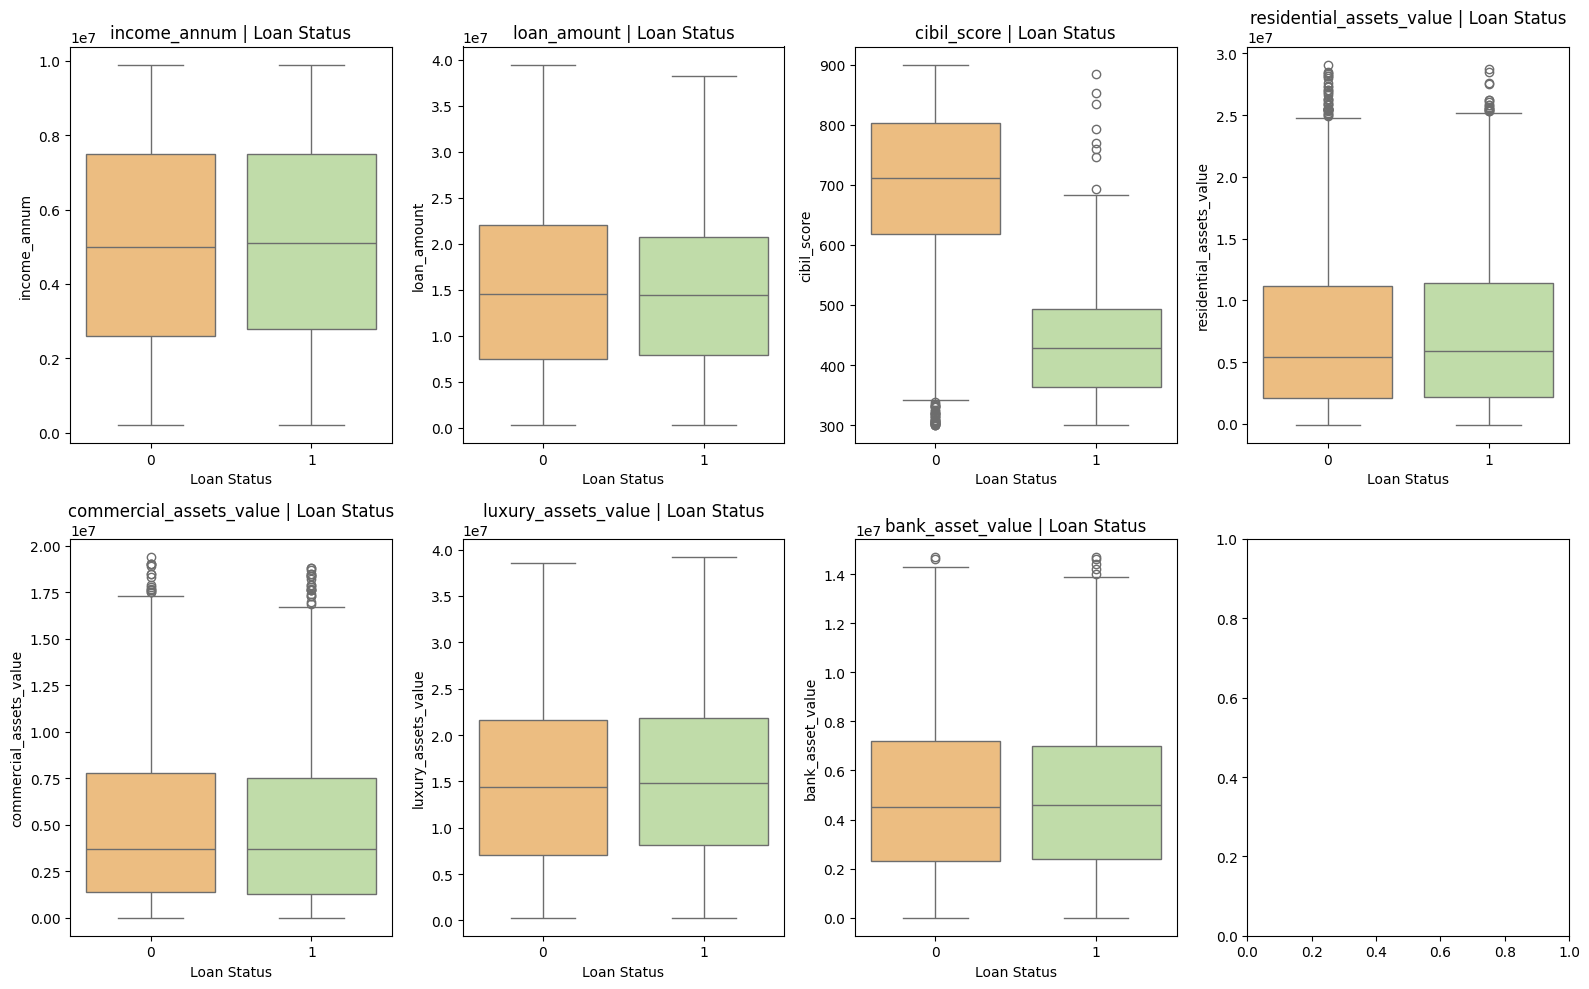

In [145]:
fig, axes = plt.subplots(2,4,figsize = (16,10))

for col, ax in zip(num_cols, axes.flatten()[:len(num_cols)]):
  sns.boxplot(data = data, y = col, x = "loan_status", ax = ax, palette = "Spectral")
  ax.set_title(f"{col} | Loan Status")
  ax.set_xlabel("Loan Status")
  ax.set_ylabel(col)

plt.tight_layout()
plt

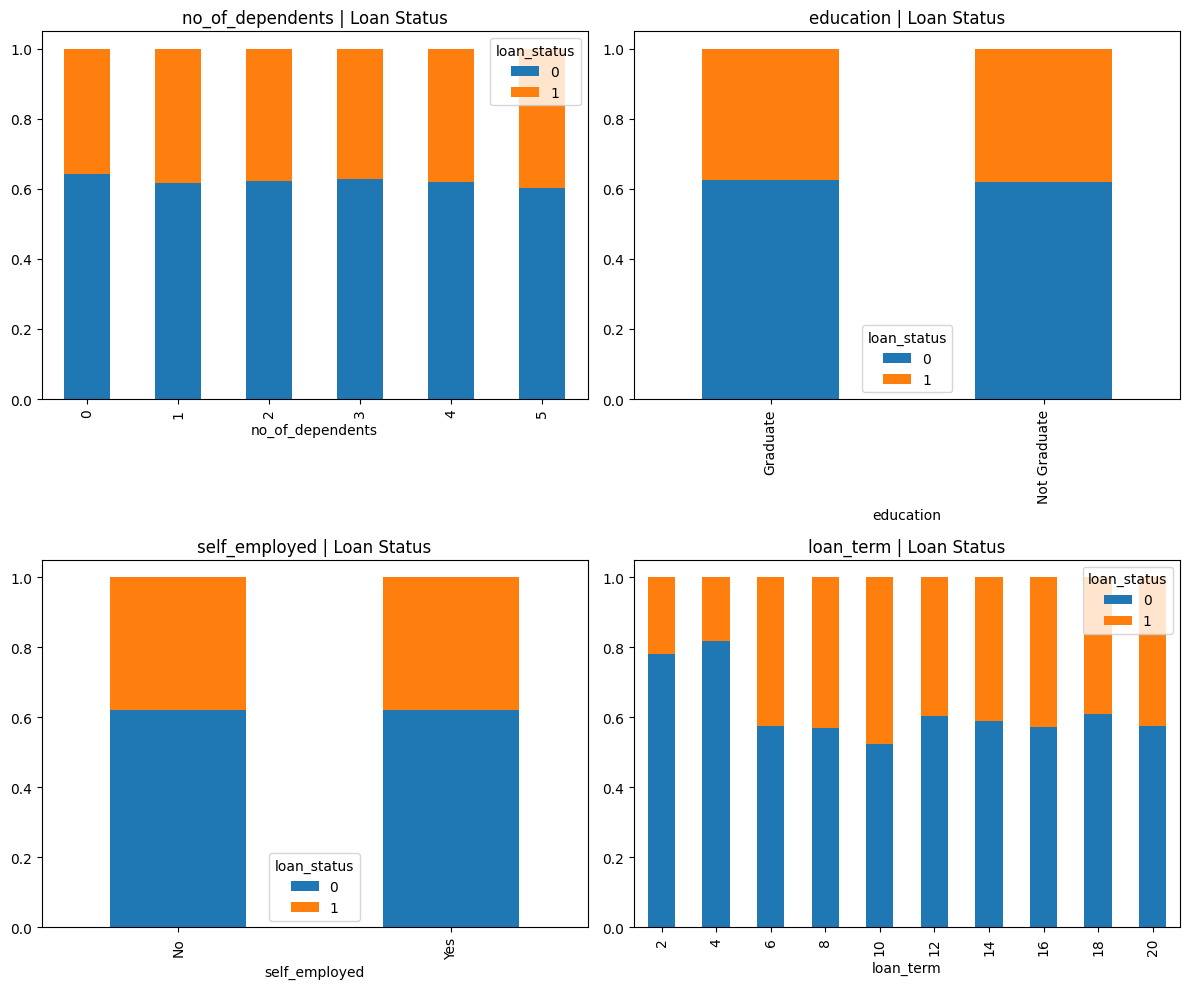

In [147]:
fig, axes = plt.subplots(2,2,figsize = (12,10))

for col, ax in zip(cat_cols, axes.flatten()[:len(cat_cols)]):
  grouped = data.groupby(col)["loan_status"].value_counts(normalize=True).unstack() #unstack sirve para
  grouped.plot(kind="bar", stacked=True, ax=ax)
  ax.set_title(f"{col} | Loan Status")
  ax.set_xlabel(col)
plt.tight_layout()
plt.show()

### Análisis multivariado

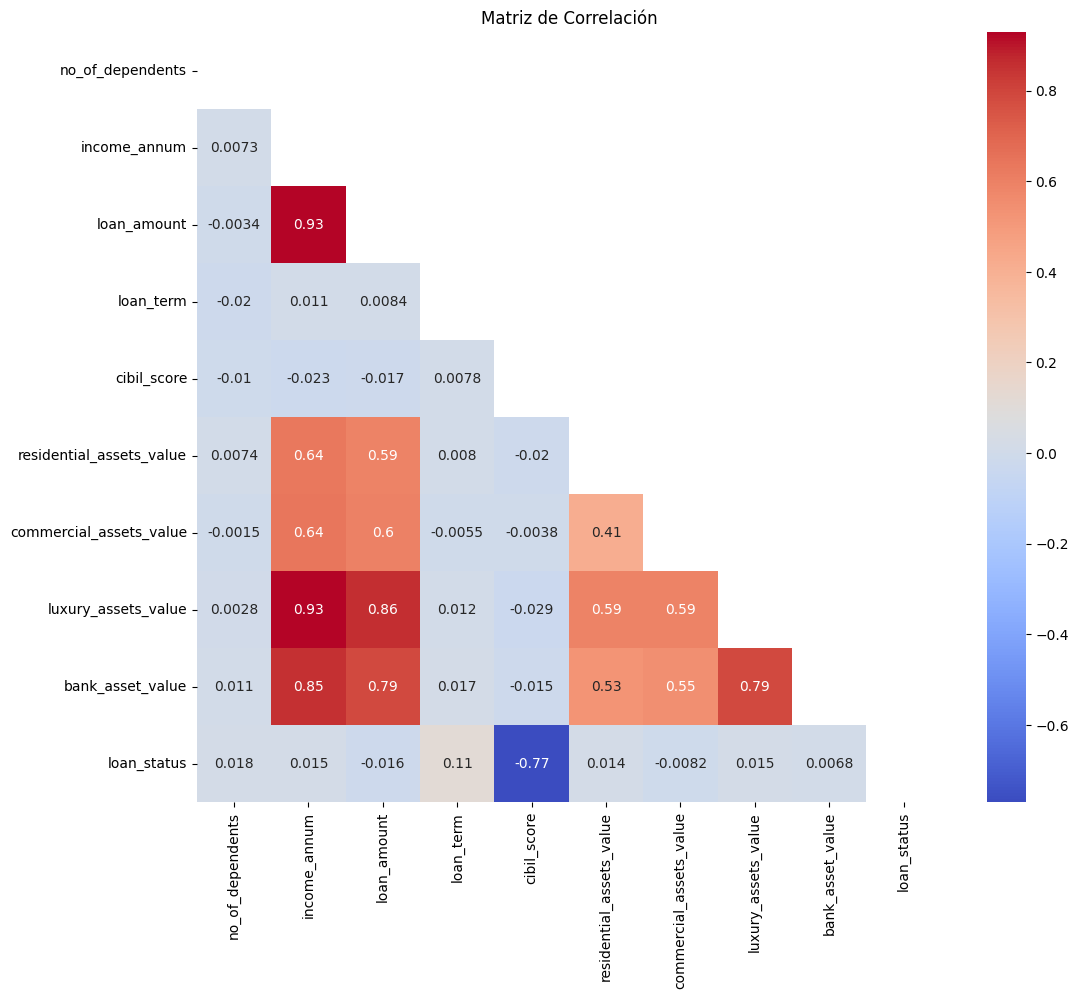

In [139]:
corr = data.select_dtypes("number").corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(12, 10))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show() #Las variables tienen poca o ninguna correlación con la variable target

Tras realizar el análisis exploratorio, verificamos que las variables de este dataset son poco útiles para poder diferenciar entre la clase buena y mala del target. En ese sentido, esperamos métricas poco alentadoras del modelo

##CLASES

Generamos 3 clases para poder mejorar el poder predictivo del modelo:
1. Generador de ratio: Obtenemos un ratio dedua/ingreso que nos permite identificar a que porcentaje del ingreso es equivalente el monto prestado. Valores más elevados implican un mayor riesgo de impago.
2. Convertidor WoE: En lugar de escalar nuestras variables por estandarización o normalización, procedemos a aplicar transformación por Weight of Evidence (WoE), la cual identifica la relación de clase buena y mala por cada subgrupo de la variable (realiza binning). Además, filtramos las variables del modelo en base al Information Value(IV).
3. Generador Total de Activos: Para no llenarnos de columnas, creamos una clase la cual sume los distintos tipos de activos de cada cliente en uno solo.

In [122]:
class RatioGenerator(BaseEstimator, TransformerMixin):
  """
  Clase que genera un ratio entre dos columnas.
  Atributos:
  -----------
  cols: list
    Lista de columnas con las cuales generar el ratio (len = 2)
  column_name: str
    Nombre de la columna generada (loan_income_ratio por default)
  """
  def __init__(self,cols,column_name="loan_income_ratio"):
    self.cols = cols
    self.column_name = column_name
  def fit(self,X,y=None):
    return self
  def transform(self,X):
    X_copy = X.copy()
    numerador = X_copy[self.cols[0]]
    denominador = X_copy[self.cols[1]]
    ratio = np.where(denominador == 0, np.nan, numerador / denominador)
    nombre_columna = self.column_name
    X_copy[nombre_columna] = ratio
    return X_copy[[nombre_columna]]
  def get_feature_names_out(self, input_features=None):
      return np.array([self.column_name])

In [123]:
class WoeGenerator(BaseEstimator, TransformerMixin):
    """
    Transformador de Weight of Evidence (WoE) con filtrado por Information Value (IV).

    Esta clase discretiza variables numéricas y codifica tanto numéricas como categóricas
    basándose en su relación logarítmica con el target. Automatiza la selección de
    características eliminando aquellas con un IV inferior al umbral definido.

    Parámetros:
    -----------
    bins : int, default=5
        Número de intervalos para la discretización de variables numéricas.
    iv_threshold : float, default=0.02
        Umbral mínimo de Information Value para mantener una variable.
    """
    def __init__(self, bins=5, iv_threshold=0.02):
        self.bins = bins
        self.iv_threshold = iv_threshold
        self.woe_tables_ = {}
        self.iv_values_ = {}
        self.features_to_keep_ = []
        self.bin_cuts_ = {} # Guardamos los límites de los cortes

    def fit(self, X, y):
        X_df = pd.DataFrame(X).copy()
        y_series = pd.Series(y).reset_index(drop=True)
        X_df = X_df.reset_index(drop=True)

        self.woe_tables_ = {}
        self.iv_values_ = {}
        self.features_to_keep_ = []
        self.bin_cuts_ = {}

        for col in X_df.columns:
            if pd.api.types.is_numeric_dtype(X_df[col]):
                # Aprendemos los límites de los cortes en el set de entrenamiento
                _, bins_edges = pd.qcut(X_df[col], q=self.bins, duplicates="drop", retbins=True)
                # Ajustamos los límites para cubrir valores fuera del rango de entrenamiento
                bins_edges[0], bins_edges[-1] = -np.inf, np.inf
                self.bin_cuts_[col] = bins_edges
                x_binned = pd.cut(X_df[col], bins=self.bin_cuts_[col])
            else:
                x_binned = X_df[col]

            df_temp = pd.DataFrame({"feature": x_binned, "target": y_series})
            stats = df_temp.groupby("feature", observed=True)["target"].agg(["count", "sum"])
            stats.columns = ["total", "bad"]
            stats["good"] = stats["total"] - stats["bad"]

            bad_sum = stats["bad"].sum()
            good_sum = stats["good"].sum()

            stats["bad_rate"] = stats["bad"] / (bad_sum if bad_sum > 0 else 1)
            stats["good_rate"] = stats["good"] / (good_sum if good_sum > 0 else 1)

            stats["woe"] = np.log((stats["good_rate"] + 0.0001) / (stats["bad_rate"] + 0.0001))
            iv = ((stats["good_rate"] - stats["bad_rate"]) * stats["woe"]).sum()

            self.woe_tables_[col] = stats['woe'].to_dict()
            self.iv_values_[col] = iv

            if iv >= self.iv_threshold:
                self.features_to_keep_.append(col)

        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).copy()
        X_transformed = pd.DataFrame(index=X_df.index)

        for col in self.features_to_keep_:
            if col in self.bin_cuts_:
                # Aplicamos los cortes aprendidos en el fit
                x_binned = pd.cut(X_df[col], bins=self.bin_cuts_[col])
            else:
                x_binned = X_df[col]

            X_transformed[col] = (x_binned.map(self.woe_tables_[col])
                                          .astype(float)
                                          .fillna(0))
        return X_transformed

    def get_feature_names_out(self, input_features=None):
        return np.array(self.features_to_keep_)


In [124]:
class TotalAssetsGenerator(BaseEstimator,TransformerMixin):
  """
  Calculamos los Asset totales de cada cliente en base a un conjunto de columnnas en lista.
  Atributos:
  ------------
  columns: list
    Lista de columnas con las cuales calcular el total.
  column_name: str
    Nombre de la columna generada (Por default total_asset)
  """
  def __init__(self,columns,column_name="total_asset"):
    self.columns = columns
    self.column_name = column_name
  def fit(self,X,y=None):
    return self
  def transform(self,X):
    X_copy = X.copy()
    X_copy[self.column_name] = X_copy[self.columns].sum(axis=1)
    return X_copy[[self.column_name]]
  def get_feature_names_out(self, input_features=None):
        return np.array([self.column_name])

##PREPROCESAMIENTO

In [125]:
train = data.drop("loan_status",axis=1)
target = data.loan_status
X_train,X_test,y_train,y_test = train_test_split(train,target,test_size=0.2,random_state = 42,stratify = target)

In [126]:
feature_eng = ColumnTransformer([
    # 1. Creamos Ratio y eliminamos las originales de la rama (loan_amount, income_annum)
    ('ratio_deuda', RatioGenerator(cols=['loan_amount', 'income_annum']), ['loan_amount', 'income_annum']),

    # 2. Creamos Assets y eliminamos las 4 originales de la rama
    ('assets_totales', TotalAssetsGenerator(columns=['residential_assets_value',
                                                     'commercial_assets_value',
                                                     'luxury_assets_value',
                                                     'bank_asset_value']),
                                                     ['residential_assets_value',
                                                      'commercial_assets_value',
                                                      'luxury_assets_value',
                                                      'bank_asset_value']),

    # 3. Dejamos pasar SOLO las que queremos mantener intactas
    ('mantener', 'passthrough', ['no_of_dependents', 'education', 'self_employed', 'loan_term', 'cibil_score'])

], remainder='drop')

In [127]:
pipe_final = Pipeline([
    ('ingenieria', feature_eng),
    # Aquí podrías poner un Imputer si hubiera nulos
    ('woe_filter', WoeGenerator(bins=10, iv_threshold=0.005)),
    ('modelo', LogisticRegression(class_weight='balanced'))
]).set_output(transform="pandas")


##MODELO

In [128]:
pipe_final.fit(X_train,y_train)

Pipeline(steps=[('ingenieria',
                 ColumnTransformer(transformers=[('ratio_deuda',
                                                  RatioGenerator(cols=['loan_amount',
                                                                       'income_annum']),
                                                  ['loan_amount',
                                                   'income_annum']),
                                                 ('assets_totales',
                                                  TotalAssetsGenerator(columns=['residential_assets_value',
                                                                                'commercial_assets_value',
                                                                                'luxury_assets_value',
                                                                                'bank_asset_value']),
                                                  ['residential_assets_value',
                                                   'commercial_assets_value',
                                                   'luxury_assets_value',
                                                   'bank_asset_value']),
                                                 ('mantener', 'passthrough',
                                                  ['no_of_dependents',
                                                   'education', 'self_employed',
                                                   'loan_term',
                                                   'cibil_score'])])),
                ('woe_filter', WoeGenerator(bins=10, iv_threshold=0.005)),
                ('modelo', LogisticRegression(class_weight='balanced'))])

In [129]:
y_pred = pipe_final.predict(X_test)

In [130]:
print("="*60)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97       531
           1       0.94      0.96      0.95       323

    accuracy                           0.96       854
   macro avg       0.96      0.96      0.96       854
weighted avg       0.96      0.96      0.96       854

